# Notebook 02: Baseline Model — Logistic Regression 

**Project:** ChurnOps — End-to-End MLOps for Customer Churn Prediction 
**Purpose:** Establish a minimum performance floor using a simple, interpretable logistic Regression Model before moving to tree-based model.
- Apply preprocessing decisions from EDA 
- Train an unregularized Logistic Regression as a sanity-check baseline 
- Evaluate on validation set using the project metrics: ROC-AUC, Precision@20%, Recall@20%, F1 
- Identify which features the linear model uses most (coefficients)
- Set the bar that XGBoost and LightGBM must beat 

**Outcome:** A baseline performance number and a reusable preprocessing pipeline that feeds directly into Notebook 03.

## Table of Contents 

1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Quick Validation](#2-data-loading--quick-validation)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Train/Validation Split](#4-trainvalidation-split)
5. [Logistic Regression — Baseline Training](#5-logistic-regression--baseline-training)
6. [Evaluation — Standard Metrics](#6-evaluation--standard-metrics)
7. [Evaluation — Top-20% Metrics](#7-evaluation-top-20-metrics)
8. [Feature Importance (Coefficients)](#8-feature-importance-coefficients)
9. [Threshold Selection](#9-threshold-selection)
10. [Conclusions & Next Steps](#10-conclusions--next-steps)

## 1. Setup & Imports 

We imports libraries needed for data loading, preprocessing, logitic regression, and evaluation.
We reuse the same configuration style as Notebook 01 for consistency.

In [1]:
# === Standard Library ===
import os
import warnings

# === Third-party: Data & Numerics ===
import numpy as np
import pandas as pd

# === Third-party: Preprocessing & Modeling ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# === Third-Party: Evaluation ===
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# === Third-Party: Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuration ===
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

DATA_PATH = os.path.join("..", "data", "raw", "WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2. Data Loading & Quick Validation 

We load the raw CSV and apply the two fixes identified in Notebook 01:
1. Conert `TotalCharges` from object to numeric, filling blanks with 0
2. Drop the 22 duplicate rows 

We then verify the resulting shape and column types.

In [2]:
# Load raw data
df = pd.read_csv(DATA_PATH)

# Fix 1: Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Fix 2: Drop duplicate rows (excluding customerID)
initial_rows = len(df)
df = df.drop_duplicates(subset=df.columns.drop("customerID"), keep="first")
print(f"Dropped {initial_rows - len(df)} duplicate rows. Remainng: {len(df)}")

# Verify
print(f"\nShape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNulls:\n{df.isnull().sum().sum()}")

Dropped 22 duplicate rows. Remainng: 7021

Shape: (7021, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Nulls:
0


## 3. Preprocessing Pipeline 

Based on EDA findings (Notebook 01, Section 10.1), we build a preprocesing pipeline that:

1. **Drops** `customerID` (identifier, not a feature)
2. **Encodes** the target `Churn` from Yes/No to 1/0.
3. **Collapses** `"No internet service"` and `"No phone service"` to `"No"` in all affected columns 
4. **Standardizes** binary columns to 0/1
5. **One-hot encodes** all categorical features 
6. **Scales** numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`)

We define the column groups first, then build a `ColumnTransformer` + `Pipeline` that will be reused in subsequent notebooks and the production pipeline. 

In [3]:
# === Column Group Definitions ===

# Identifier (to drop)
id_col = "customerID"

# Target
target_col = "Churn"

# Numerical features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Binary categorical features (Yes/No or 0/1 after cleanup)
binary_cols = ["gender", "SeniorCitizen", "Partner", "Dependents",
               "PhoneService", "PaperlessBilling"]

# Multi-category features (some with "No internet service" / "No phone service")
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity",
                  "OnlineBackup", "DeviceProtection", "TechSupport",
                  "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

# Columns where "No internet service" or "No phone service" should collapse to "No"
collapse_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                 "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

print(f"ID column: {id_col}")
print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Binary features ({len(binary_cols)}): {binary_cols}")
print(f"Multi-category features ({len(multi_cat_cols)}): {multi_cat_cols}")
print(f"Collapse-to-No columns ({len(collapse_cols)}): {collapse_cols}")

ID column: customerID
Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary features (6): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category features (10): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Collapse-to-No columns (7): ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [5]:
# === Manual Preprocessing Steps (before ColumnTransformer) ===

def preprocess_manual(df):
    """
    Apply manual cleaning steps that are easier to do in pandas
    before feeging into sklearn's ColumnTransformer
    """
    df = df.copy()

    # 1. Drop customerID
    df = df.drop(columns=[id_col])

    # 2. Encode target: Yes -> 1, No -> 0
    df[target_col] = df[target_col].map({"Yes": 1, "No": 0})

    # 3. Collapse "No internet service" and "No phone service" to "No"
    for col in collapse_cols:
        df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

    # 4. Standardize binary Yes/No columns to 0/1
    for col in binary_cols:
        if col == "SeniorCitizen":
            continue # Already 0/1
        df[col] = df[col].map({"Yes": 1, "No": 0})

    return df

# Apply
df_clean = preprocess_manual(df)

# Verify
print("=== Target Encoding ===")
print(df_clean[target_col].value_counts())
print(f"\n=== Binary columns (first 3) ===")
print(df_clean[binary_cols].head(3))
print(f"\n=== Collapsed columns sample ===")
for col in collapse_cols:
    print(f"{col}: {df_clean[col].unique().tolist()}")

=== Target Encoding ===
Churn
0    5164
1    1857
Name: count, dtype: int64

=== Binary columns (first 3) ===
   gender  SeniorCitizen  Partner  Dependents  PhoneService  PaperlessBilling
0     NaN              0        1           0             0                 1
1     NaN              0        0           0             1                 0
2     NaN              0        0           0             1                 1

=== Collapsed columns sample ===
MultipleLines: ['No', 'Yes']
OnlineSecurity: ['No', 'Yes']
OnlineBackup: ['Yes', 'No']
DeviceProtection: ['No', 'Yes']
TechSupport: ['No', 'Yes']
StreamingTV: ['No', 'Yes']
StreamingMovies: ['No', 'Yes']


In [6]:
# === Sklearn ColumnTransformer ===

# Preprocessing for numerical features: standard scaling
num_transformer = StandardScaler()

# Preprocessing for multi-category featues: one-hot encoding
cat_transformer = OneHotEncoder(drop="first", sparse_output=False)

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, multi_cat_cols)
    ],
    remainder="passthrough" # binary_cols pass through unchanged (already 0/1)
)

# Full preprocessing pipeline (without model)
preprocess_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
        ]
)

# Display transformer structure
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies', 'Contract',
                                  'PaymentMethod'])])

# Train/Validation Split 

We perform a stratified 72/25 split (training = 60% of full data, validation 20% of full data, test held for later).
For this baseline notebook we only need train + validation. The held-out test set will be used in notebook 03 for final model comparison.

Stratification preserves the 226.5% churn rate in both splits.

In [16]:
# Separat features and target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Stratified split: 75% train, 25% validation (equivalent to 60/20 of full data)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows ({y_train.mean():.2%} churn)")
print(f"Validation set: {X_val.shape[0]} rows ({y_val.mean():.2%} churn)")
print(f"Churn rate preserved: Train {y_train.mean():.4f} vs Val {y_val.mean():.4f}")

Training set: 5265 rows (26.46% churn)
Validation set: 1756 rows (26.42% churn)
Churn rate preserved: Train 0.2646 vs Val 0.2642


## 5. Logistic Regression — Baseline Training 

We train a simple Logistic Regression with default hyperparameters (no tuning).
This is the **dumbest reasonable model** — if XGBoost can't beat this, something is wrong.

We wrap preprocessing + model into a single sklearn `Pipeline` so it can be applied to new data without leakage.

In [19]:
# Diagnose NaN source: check preprocessed output
from sqlalchemy import null


X_train_transformed = preprocessor.fit_transform(X_train)

print(f"Any NaN in transformed X_train: {np.isnan(X_train_transformed).any()}")
print(f"NaN count: {np.isnan(X_train_transformed).sum()}")

Any NaN in transformed X_train: True
NaN count: 5265


In [20]:
print("=== RAW X_train: null counts ===")
null_counts = X_train.isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) > 0:
    display(null_cols)
else:
    print("No nulls in raw X_train")

print("\n=== RAW X_train: unexpected values in multi_cat_cols ===")
for col in multi_cat_cols:
    vals = X_train[col].unique()
    unexpected = [v for v in vals if v not in ["Yes", "No"]]
    if unexpected:
        print(f"{col}: {unexpected}")

print("\n=== RAW X_train: unexpected values in binary_cols ===")
for col in binary_cols:
    vals = X_train[col].unique()
    unexpected = [v for v in vals if v not in [0, 1]]
    if unexpected:
        print(f"{col}: {unexpected}")

=== RAW X_train: null counts ===


gender    5265
dtype: int64


=== RAW X_train: unexpected values in multi_cat_cols ===
InternetService: ['Fiber optic', 'DSL']
Contract: ['Month-to-month', 'One year', 'Two year']
PaymentMethod: ['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)']

=== RAW X_train: unexpected values in binary_cols ===
gender: [np.float64(nan)]


**Root Cause:** `gender` was incorrectly grouped in `binary_cols` and mapped via `{"Yes": 1, "No": 0}`, destroying all values since gender contains `"Male"/"Female"`.

**Fix:** Move `gender` to `multi_cat_cols` since it needs one-hot encoding, not binary mapping. Rebuild column groups and rerun preprocessing.

In [ ]:
# === Corrected Column Group Definitions ===

# Numerical features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Binary categorical features (Yes/No only, or already 0/1)
binary_cols = ["SeniorCitizen", "Partner", "Dependents",
               "PhoneService", "PaperlessBilling"]

# Multi-category features (including gender, which is Male/Female)
multi_cat_cols = ["gender", "MultipleLines", "InternetService", "OnlineSecurity",
                  "OnlineBackup", "DeviceProtection", "TechSupport",
                  "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

# Columns where "No internet service" or "No phone service" should collapse to "No"
collapse_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                 "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Binary features ({len(binary_cols)}): {binary_cols}")
print(f"Multi-category features ({len(multi_cat_cols)}): {multi_cat_cols}")

Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary features (5): ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category features (11): ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [24]:
# Re-apply manual preprocessing with corrected column groups
def preprocess_manual_v2(df):
    df = df.copy()

    # 1. Drop customerID
    df = df.drop(columns=[id_col])

    # 2. Encode target: Yes -> 1, No -> 0
    df[target_col] = df[target_col].map({"Yes": 1, "No": 0})

    # 3. Collapse "No internet service" and "No phone service" to "No"
    for col in collapse_cols:
        df[col] = df[col].replace(
            {"No internet service": "No",
             "No phone service": "No"
             }
        )

    # 4. Standardize binary Yes/No columns to 0/1 (gender excluded)
    for col in binary_cols:
        if col == "SeniorCitizen":
            continue # Already 0/1
        df[col] = df[col].map({"Yes": 1, "No": 0})

    return df

df_clean = preprocess_manual_v2(df)
# Verify gender survived
print("=== Gender values ===")
print(df_clean["gender"].value_counts())
print(f"\n=== All nulls: {df_clean.isnull().sum().sum()} ===")

=== Gender values ===
gender
Male      3541
Female    3480
Name: count, dtype: int64

=== All nulls: 0 ===


In [25]:
# Rebuld ColumnTransformer with corrected column groups
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop="first", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, multi_cat_cols)
    ],
    remainder="passthrough"         # binary_cols pass through
)

# Re-split
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Verify no NaN in transformed output
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"NaN in transformed X_train: {np.isnan(X_train_transformed).any()}")
print(f"Transformed shape: {X_train_transformed.shape}")

NaN in transformed X_train: False
Transformed shape: (5265, 23)


In [27]:
# Build full pipeline: preprocessing + Logistic Regression
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train
baseline_pipeline.fit(X_train, y_train)

# Predict probabilities on validation set
y_val_proba = baseline_pipeline.predict_proba(X_val)[:, 1]
y_val_pred = baseline_pipeline.predict(X_val)

print("Training complete.")
print(f"Mean predicted probability: {y_val_proba.mean():.4f}")
print(f"Predicted churn rate at 0.5 threshold: {y_val_pred.mean():.2%}")

Training complete.
Mean predicted probability: 0.4106
Predicted churn rate at 0.5 threshold: 40.95%


**Observations:**

- The model predicts a mean churn probability of 41.1%, significantly higher than the actual validation churn rate (~26.5%).
- At the default 0.5 threshold, 41% of customers are flagged as churners — this is a high false-positive rate driven by `class_weight="balanced"`.
- We'll need threshold tuning to align predictions with the business goal of targeting the top 20% highest-risk customers.
- For now, we proceed to evaluate the model's ranking quality (ROC-AUC) and top-20% precision/recall.

## 6. Evaluation — Standard Metrics 

We evaluate the baseline model on the validation set using:
- **ROC-AUC** — measures ranking quality across all thresholds
- **Classification report** — precision, recall, F1 at the default 0.5 threshold
- **Confusion matrix** — to see the raw counts 
- **ROC curve** — visual inspection of the trade-off

In [28]:
# Standard Metrics
auc = roc_auc_score(y_val, y_val_proba)
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)

print("=== Baseline Logistic Regression - Validation Metrics ===")
print(f"ROC-AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"\n=== Classification Report ===")
print(classification_report(y_val, y_val_pred, target_names=["No (0)", "Yes (1)"]))

=== Baseline Logistic Regression - Validation Metrics ===
ROC-AUC: 0.8440
Precision: 0.5090
Recall: 0.7888
F1-score: 0.6188

=== Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.91      0.73      0.81      1292
     Yes (1)       0.51      0.79      0.62       464

    accuracy                           0.74      1756
   macro avg       0.71      0.76      0.71      1756
weighted avg       0.80      0.74      0.76      1756



**Observations:**

- **ROC-AUC = 0.844** — strong baseline. Exceeds the 0.80 threshold from the spec. A simple linear model already separates churners from non-churners well.
- **Precision = 0.509** at default threshold — when we predict churn, we're right ~51% of the time. Decent but below the 0.60 target.
- **Recall = 0.789** — we capture ~79% of actual churners  at the default threshold. This exceeds the 0.68 target but comes at the cost of many false positives.
- The imbalance is visible: 41% predicted churn vs 26.5% actual. The model over-predicts churn due to `class_weight="balanced"`.

**Key takeaway:** Ranking is solid (AUC 0.84). We need threshold tuning to hit the top-20% precision/recall targets, not the default 0.5 cutoff.

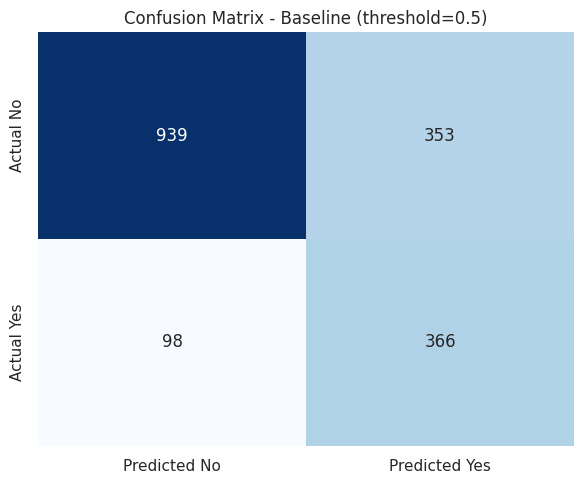

In [31]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

fix, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Predicted No", "Predicted Yes"],
            yticklabels=["Actual No", "Actual Yes"])

ax.set_title("Confusion Matrix - Baseline (threshold=0.5)")
plt.tight_layout()
plt.show()

**Observations:**

- **True Negatives:** 939 — correctly identified non-churners 
- **False Positives:** 353 — flagged as churn but didn't leave. These represent wasted retention spend
- **False negatives:** 98 — missed churners. Lost customers we could have tried to save 
- **True Positives:** 366 — correctly caught churners 

At the 0.5 threshold, the false positive count (353) is nearly as high as the true positive count (366). This is too noisy for a retention campaign. We need a higher threshold to improve precision at the expense of recall — consistent with the top-20% targeting strategy.

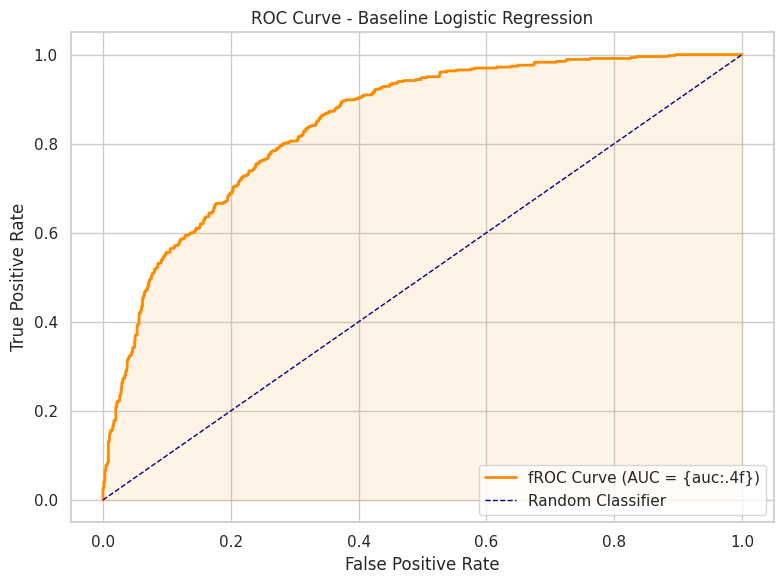

In [32]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="darkorange", lw=2,
        label="fROC Curve (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--",
        label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="darkorange")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Baseline Logistic Regression")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observations:**

- The ROC curve rises steeply towards the top-left corner — the model ranks well 
- AUC = 0.844 confirms strong discriminative power for a baseline 
- The curve is smooth, no abrupt jumps — the model's probability estimates are well-calibrated in rank order 
- To target the top 20% highest-risk customers, we need to find the threshold corresponding to the 80th percentile of predicted probabilities — this comes next 

## 7. Evaluation — Top-20% Metrics 

The business objective is to target the top 20% highest-risk customers.
We now:

1. Find the probability threshold that isolates the top 20% of predictions
2. Compute Precision@20%, Recall@20%, and F1@30% at that threshold 
3. Compare against spec targets: Precision > 0.60, Recall > 0.68

In [36]:
# Find threshold for top 20% highest-risk customers
top_20_pct_threshold = np.percentile(y_val_proba, 80)
print(f"Threshold for top 20%: {top_20_pct_threshold}")

# Apply threshold
y_val_pred_top20 = (y_val_proba >= top_20_pct_threshold).astype(int)

# Metrics at this threshold
precision_top20 = precision_score(y_val, y_val_pred_top20)
recall_top20 = recall_score(y_val, y_val_pred_top20)
f1_top20 = f1_score(y_val, y_val_pred_top20)

# Proportion of customers flagged
flagged_pct = y_val_pred_top20.mean() * 100

print(f"\n=== Top-20% Threshold Metrics ===")
print(f"Threshold:          {top_20_pct_threshold:.4f}")
print(f"Customers flagged:  {flagged_pct:.1f}%")
print(f"Precision@20%:      {precision_top20:.4f}   (target > 0.60)")
print(f"Recall@20:      {recall_top20:.4f}       (target > 0.68)")
print(f"F1@20%:     {f1_top20:.4f}           (target > 0.55)")


Threshold for top 20%: 0.7483620745457132

=== Top-20% Threshold Metrics ===
Threshold:          0.7484
Customers flagged:  20.0%
Precision@20%:      0.6875   (target > 0.60)
Recall@20:      0.5216       (target > 0.68)
F1@20%:     0.5931           (target > 0.55)


**Observations:**

| **Metric** | **Baseline** | **Target** | **Status** |
|------------|--------------|------------|------------|
| Precision@20% | 0.688 | > 0.60 | ✅ Pass |
| Recall@30% | 0.522 | > 0.68 | ❌ Fail |
| F1@20% | 0.593 | > 0.55 | ✅ Pass |

- **Precision is strong:** 68.8% of flagged customers actually churn. Exceeds the 0.60 target comfortably 
- **Recall misses the mark:** We only capture 52.2% of actual churners in the top 20% flag. The spec requires > 68%.
- The baseline model is conservative — it's precise but misses too many churners.

**Diagnosis:** Logistic Regression is a linear model. It can't capture interactions (e.g., Tenure x Contract) that we identified in EDA. A tree-based model like XGBoost should improve recall by learning non-linear decision boundaries and interactions.

The baseline sets a credible floor. XGBoost must beat these numbers, particularly Recall@20%.

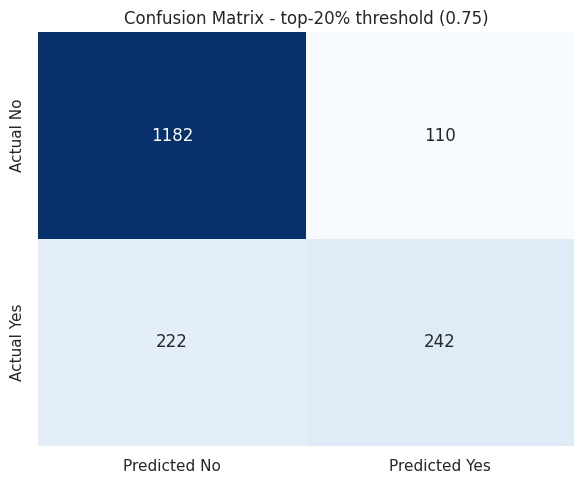

False Positives (wasted spend): 110
False Negatives (missed churn): 222
True Positives (saved): 242


In [39]:
# Confusion matrix at top-20% threshold
cm_top20 = confusion_matrix(y_val, y_val_pred_top20)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_top20, annot=True, fmt="d", cmap="Blues", cbar=False,
            ax=ax, xticklabels=["Predicted No", "Predicted Yes"],
            yticklabels=["Actual No", "Actual Yes"]
            )
ax.set_title(f"Confusion Matrix - top-20% threshold ({top_20_pct_threshold:.2f})")
plt.tight_layout()
plt.show()

print(f"False Positives (wasted spend): {cm_top20[0, 1]}")
print(f"False Negatives (missed churn): {cm_top20[1, 0]}")
print(f"True Positives (saved): {cm_top20[1, 1]}")

**Observations:**

Compared to the 0.5 threshold:

| | **0.5 Threshold** | **Top-20% Threshold** | **Change** |
| --- | --- | --- | --- |
| False Positives | 353 | 110 | **-243** (less waste) |
| False Negatives | 98 | 222 | **+124** (more missed) |
| True Positives | 366 | 242 | **-124** (fewer saved) |

The top-20% threshold is a stricter bar. It reduces false positives dramatically (from 353 to 110) — good for retention budget. But it also misses 222 churners vs 98 at the default threshold.

The trade-off is clear: precision ↑, recall ↓. The question is whether XGBoost can push both numbers higher simultaneously by learning interactions that Logistic Regression misses.

## 8. Feature Importance (Coefficients)

Logistic Regression coefficients shows which features push churn probability up or down.
We extract the coefficient for each feature, sort by magnitude, and visualize the top 15.

Positive coefficient → increases churn risk 
Negative coefficient → decreases churn risk 

We must also recover the feature names from the ColumnTransformer (after one-hot encoding) to label the coefficients correctly.

In [40]:
# Extract coefficients and feature names
lr_model = baseline_pipeline.named_steps["classifier"]
preprocessor_fitted = baseline_pipeline.named_steps["preprocessor"]

# Get feature names after one-hot encoding
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
num_names = num_cols
cat_names = list(cat_encoder.get_feature_names_out(multi_cat_cols))
binary_names = binary_cols # passthrough
all_feature_names = num_names + cat_names + binary_names

# Get coefficients
coefficients = lr_model.coef_[0]

# Build DataFrame
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients,
    "abs_coef": np.abs(coefficients)
}).sort_values("abs_coef", ascending=False)

# Display top 15
coef_df.head(15)

,feature,coefficient,abs_coef
14,Contract_Two year,-1.3935,1.3935
0,tenure,-1.3483,1.3483
6,InternetService_No,-1.0061,1.0061
5,InternetService_Fiber optic,0.8666,0.8666
2,TotalCharges,0.6930,0.6930
13,Contract_One year,-0.6919,0.6919
21,PhoneService,-0.5057,0.5057
22,PaperlessBilling,0.3610,0.3610
16,PaymentMethod_Electronic check,0.3557,0.3557
7,OnlineSecurity_Yes,-0.3236,0.3236


**Observations:**

**Top churn reducers (negative coefficients — customers likely to stay):**
1. **Contract_Two year: -1.39** — largest effect. Two-year contract massively reduces churn risk. Matches EDA (3% churn).
2. **tenure: -1.35** — nearly equal to two-year contract. Longer tenure strongly protective.
3. **InternetService_No: -1.01** — no internet = very low churn. Matches EDA (7.4% churn).
4. **Contract_One year: -0.69** — one-year contracts also protective, but half the effect of two-year.

**Top churn predictors (positive coefficients — customers at risk):**
1. **InternetService_Fiber: +0.87** — fiber internet strongly increases churn. Matches EDA (41.7%).
2. **TotalCharges: +0.69** — after tenuring out the negative effect of tenure, higher total charges independently increase risk.
3. **PaymentMethod_Electronic check: +0.36** — matches EDA (45.3% churn for this group).
4. **PaperlissBilling: +0.36** — digital-only customers at higher-risk.

**Key insight:** Contract type and tenure dominate the linear model, just as they dominated the EDA. The model correctly identifies the same strongest signals. However, interactions (Tenure x Contract) remain invisible to this linear model — XGBoost will capture them.

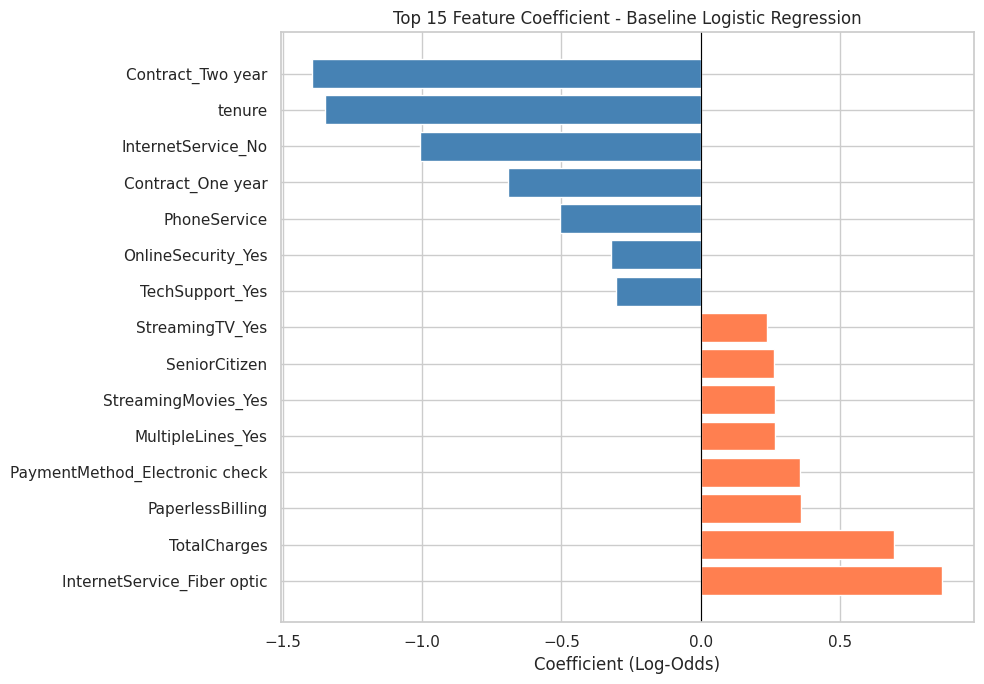

In [41]:
# Visualize top 15 coefficients
top_n = 15
coef_plot = coef_df.head(top_n).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["coral" if c > 0 else "steelblue" for c in coef_plot["coefficient"]]
ax.barh(coef_plot["feature"], coef_plot["coefficient"], color=colors, edgecolor="white")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (Log-Odds)")
ax.set_title("Top 15 Feature Coefficient - Baseline Logistic Regression")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observations:**

- Contract and tenure dominate the horizontal scale — their coefficients are 2-4x larger than the next tier
- The model is sparse in signal: the top 4 features account for the majority of predictive power. Beyond the top 6-7, coefficients decay quickly towards zero.
- `StreamingTV_Yes` and `StreamingTV_Yes` both have positive coefficients (~+0.24), matching the mild churn-increasing effect seen in EDA. Entertainment services don't drive retention.
- `SeniorCitizen` and `PaperlessBilling` confirm the EDA findings with moderate effects.

The linear view reinforces: the biggest levers for retention are contract commitment and tenure. XGBoost may reveal second-order interactions that implify or mute these effects.

## 9. Threshold Selection

The top-20% threshold is dictated by business constraints (target 20% of customers).
Here we explore the full precision-recall trade-off curve to understand:

- How metrics vary across all possible thresholds
- Where the optimal F1 score sits 
- Whether a different threshold coult hit both Precision@20% and Recall@20% targets simultaneously

This will inform threshold choice for deployment and compare against XGBoost later.

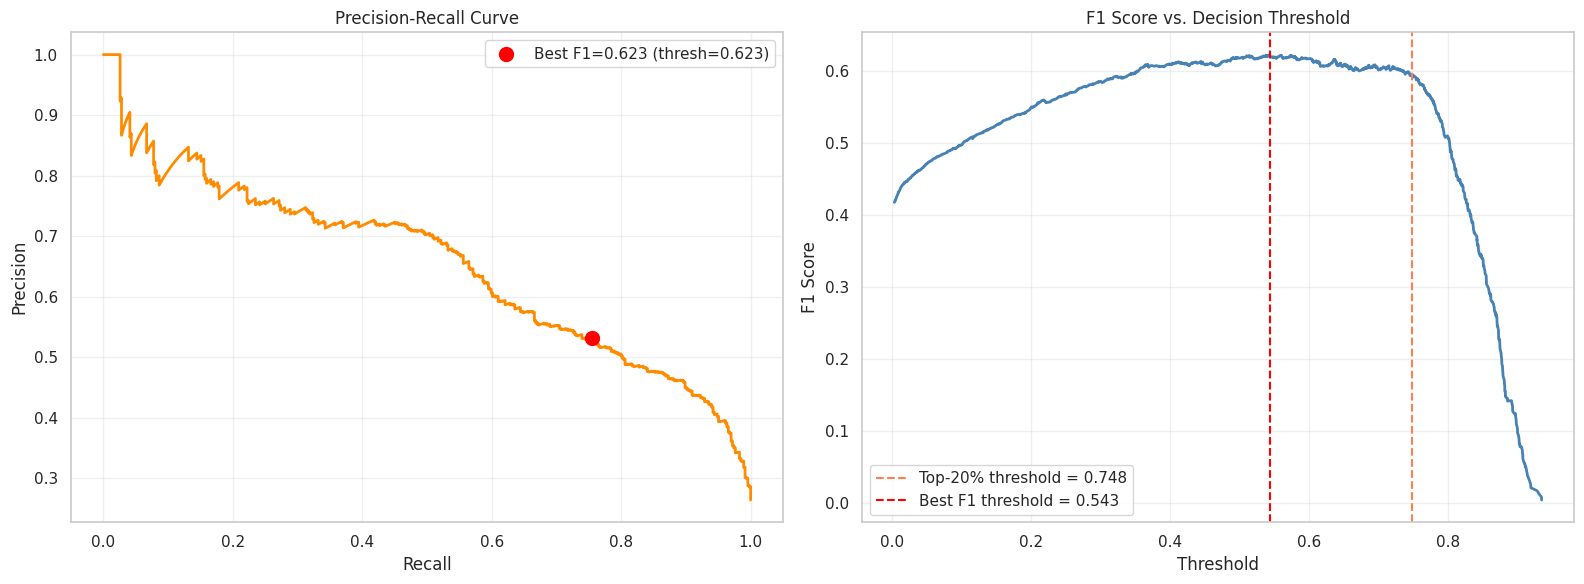

Best F1 thresholds: 0.5435 (F1 = 0.6233)
Top-20% threshold: 0.7484 (F1 = 0.5931)


In [45]:
# Precision-Recall curve across all thresholds
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_val, y_val_proba)

# F1 scores at each threshold (approximate)
# thresholds_pd has length n_thresholds; precisions/recalls have length n_thresholds+1 (last pair is for threshold=1)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] +1e-10)

# Best F1 threshold
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds_pr[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision-Recall curve
axes[0].plot(recalls, precisions, color="darkorange", lw=2)
axes[0].scatter(recalls[best_f1_idx], precisions[best_f1_idx], color="red", s=100, zorder=5,
                label=f"Best F1={best_f1:.3f} (thresh={best_f1:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: F1 vs Threshold
axes[1].plot(thresholds_pr, f1_scores, color="steelblue", lw=2)
axes[1].axvline(x=top_20_pct_threshold, color="coral", linestyle="--", lw=1.5,
                label=f"Top-20% threshold = {top_20_pct_threshold:.3f}")
axes[1].axvline(x=best_f1_threshold, color="red", linestyle="--", lw=1.5,
                label=f"Best F1 threshold = {best_f1_threshold:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs. Decision Threshold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best F1 thresholds: {best_f1_threshold:.4f} (F1 = {best_f1:.4f})")
print(f"Top-20% threshold: {top_20_pct_threshold:.4f} (F1 = {f1_top20:.4f})")

**Observations:**

- **Best F1 threshold = 0.544** — much lower than the top-20% threshold (0.748). At this threshold, the model balances precision and recall, achieving F1 = 0.623.
- **Top-20% threshold = 0.748** — more conservative. Higher precision (68.8%) but lower recall (52.2%), yielding F1 = 0.593.
- The F1 curve is relatively flat between ~0.40 and ~0.70 — the model is stable across a wide range of thresholds.

**Implication:**
- If the business constraint is stricly "target 20% of customers", we accept the top-20% threshold (0.748) and its lower recall.
- If the business would allow flagging more customers (e.g., 30-35% at the threshold ~0.54-0.60), we could capture significantly more churners with only modest precision loss.
- The optimal threshold depends on the cost of intervention vs. the cost of churn — a business decision, not purely a modeling one.

## 10. Conclusion & Next Steps 

### 10.1 Baseline Performance Summary 

| **Metric** | **Baseline (LR)** | **Spec Target** | **Satus** |
| --- | --- | --- | --- |
| ROC-AUC | 0.844 | > 0.80 | ✅ |
| Precision@20% | 0.688 | > 0.60 | ✅ |
| Recall@20% | 0.522 | > 0.68 | ❌ |
| F1@20% | 0.593 | > 0.55 | ✅ |

The baseline passes 3 out of 4 targets. Recall@20% falls short — the linear model misses too many churners in the top 20% flag.

### 10.2 Key Findings 

1. **Logistic Regression is a credible baseline.** AUC 0.844 and Precision@20% 0.688 are solid. A more complex model must earn its complexity by beating these numbers.

2. **Recall is the bottleneck.** The linear model's ranking is strong (AUC 0.84), but when forced to pick only the top 20%, it leaves 222 of 464 churners undetected.

3. **Interactions are the likely solution.** EDA revealed strong interactions (Tenure x Contract, InternetService x PaymentMethod) that a linear model cannot capture. XGBoost's tree structure should learn these directly.

4. **Preprocessing pipeline is validated.** The manual cleaning + ColumnTransformer worked correctly (after fixing the gender column grouping). This pipeline is reusable for Notebook 03 and the production pipeline.

### 10.3 Preprocessing Decisions Finalized

| **Decision** | **Implementation** |
|--------------|--------------------|
| Drop `CustomerID` | ✅ |
| Collapse "No internet service" / "No phone service" → "No" | ✅ |
| Binary Yes/No → 0/1 (except gender, which stays categorical) | ✅ |
| Scale numericals, one-hot encode multi-category | ✅ |
| Handle duplicates (22 rows dropped) | ✅ |
| TotalCharges: blank → 0 | ✅ |

### 10.4 Next Steps 

1. **Notebook 03 — Model Comparison:** Train XGBoost and LightGBM with Optunahyperparameter tuning on the same train/validation split. Compare all metrics head-to-head against baseline. The goal: beat Recall@20% while maintaining Precision@20%. 
2. **SHAP analysis** — deferred to Notebook 04 after a champion model is selected. 

**The End of Notebook 02 — Baseline Model**